# 02 — Exploration & contrôle qualité (cortex entorhinal)

**Objectif :** isoler les échantillons de **cortex entorhinal**, séparer Alzheimer (AD) et contrôles, puis contrôler la qualité des données d'expression (valeurs manquantes, échelle, distributions) et préparer une matrice **comparable entre échantillons** pour l'analyse différentielle (notebook 03).

**Pourquoi le cortex entorhinal ?** C'est la première région cérébrale touchée par la pathologie d'Alzheimer (dégénérescence neurofibrillaire précoce, stades I–II de Braak). Restreindre l'analyse à une seule région évite de mélanger des signaux biologiques hétérogènes et rend les résultats directement interprétables.

**Plan du notebook**
1. Métadonnées des échantillons → décompte exact AD / contrôle
2. Construction de la matrice d'expression (sondes × échantillons)
3. Contrôle qualité : valeurs manquantes, échelle des intensités
4. Transformation log2
5. Normalisation inter-échantillons (quantile)
6. Diagnostic ABS_CALL (taux de sondes « détectées ») — données pour la décision de filtrage à venir

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Package src/ importable depuis notebooks/
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import data_loader, preprocessing as prep

# GEOparse émet un DtypeWarning bénin sur la colonne SPOT_ID de la table
# plateforme (types mixtes) — sans impact sur les valeurs d'expression.
warnings.filterwarnings("ignore", message="Columns.*SPOT_ID.*mixed types")

sns.set_theme(style="whitegrid", context="notebook")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

gse = data_loader.load_gse()  # depuis le cache local (notebook 01)
print(f"GSE5281 chargé : {len(gse.gsms)} échantillons au total.")

GSE5281 chargé : 161 échantillons au total.


## 1. Métadonnées & décompte des groupes

On parse les caractéristiques de chaque échantillon (région, diagnostic, sexe, âge). Subtilité de GSE5281 : les clés existent en **deux casses** (`Organ Region` vs `organ region`) et les valeurs traînent des caractères parasites — `preprocessing.build_sample_metadata` normalise tout cela. On filtre ensuite le **cortex entorhinal** et on compte AD vs contrôles.

In [2]:
# Métadonnées de tous les échantillons, puis filtrage cortex entorhinal
meta_all = prep.build_sample_metadata(gse)
meta_ec = prep.filter_region(meta_all, "Entorhinal Cortex")

# ---- DÉCOMPTE EXACT (cortex entorhinal) ----
counts = meta_ec["group"].value_counts()
print("=== Cortex entorhinal : décompte des échantillons ===")
print(f"  Alzheimer (AD) : {counts.get('AD', 0)}")
print(f"  Contrôles      : {counts.get('Control', 0)}")
print(f"  TOTAL          : {len(meta_ec)}")

# Répartition sexe / âge par groupe (variables potentiellement confondantes)
print("\n=== Âge moyen et sexe par groupe ===")
display(
    meta_ec.groupby("group").agg(
        n=("group", "size"),
        age_moyen=("age", "mean"),
        age_min=("age", "min"),
        age_max=("age", "max"),
        hommes=("sex", lambda s: (s == "male").sum()),
        femmes=("sex", lambda s: (s == "female").sum()),
    ).round(1)
)

meta_ec[["title", "group", "sex", "age"]]

=== Cortex entorhinal : décompte des échantillons ===
  Alzheimer (AD) : 10
  Contrôles      : 13
  TOTAL          : 23

=== Âge moyen et sexe par groupe ===


,n,age_moyen,age_min,age_max,hommes,femmes
group,,,,,,
AD,10,85.6,78.0,97.0,4,6
Control,13,80.3,63.0,102.0,10,3


,title,group,sex,age
sample_id,,,,
GSM119615,EC control 1,Control,male,63.0
GSM119616,EC control 2,Control,male,85.0
GSM119617,EC control 3,Control,male,80.0
GSM119618,EC control 4,Control,male,80.0
GSM119619,EC control 5,Control,female,102.0
GSM119620,EC control 6,Control,male,79.0
GSM119621,EC control 7,Control,male,76.0
GSM119622,EC control 8,Control,male,83.0
GSM119623,EC control 9,Control,male,79.0


## 2. Matrice d'expression

On assemble la matrice **sondes × échantillons** restreinte aux 23 échantillons de cortex entorhinal, à partir de la colonne `VALUE` (intensités MAS5). On ordonne les colonnes par groupe pour faciliter les visualisations ultérieures.

In [3]:
# Colonnes ordonnées : contrôles puis AD
sample_order = (
    meta_ec.sort_values("group").index.tolist()
)
expr = prep.build_expression_matrix(gse, sample_order, value_col="VALUE")

print(f"Matrice d'expression : {expr.shape[0]} sondes × {expr.shape[1]} échantillons")
expr.iloc[:5, :6]

Matrice d'expression : 54675 sondes × 23 échantillons


name,GSM238763,GSM238790,GSM238791,GSM238792,GSM238793,GSM238794
probe,,,,,,
1007_s_at,1085.67000,479.4800,2104.8300,1521.09000,1492.1300,1874.3600
1053_at,7.33548,57.5863,10.5687,9.49972,10.6124,10.7383
117_at,133.62600,20.8386,65.9487,88.68500,81.3545,161.2070
121_at,521.51900,89.6319,777.7550,387.39200,479.7910,707.4530
1255_g_at,86.91590,51.6461,44.4397,49.32680,47.2470,95.6610


## 3. Contrôle qualité : valeurs manquantes & échelle

Deux vérifications avant toute transformation :
- **Valeurs manquantes / aberrantes** : présence de `NaN` ? de valeurs ≤ 0 (qui empêcheraient un passage au log) ?
- **Échelle des intensités** : les valeurs MAS5 sont des intensités *linéaires*, attendues très asymétriques (quelques sondes très intenses, beaucoup faibles). Cela motive la transformation log2.

In [4]:
n_nan = int(expr.isna().sum().sum())
n_neg = int((expr <= 0).sum().sum())
vals = expr.to_numpy()

print(f"Valeurs manquantes (NaN) : {n_nan}")
print(f"Valeurs ≤ 0              : {n_neg}")
print(f"Intensité min / médiane / max : "
      f"{vals.min():.2f} / {np.median(vals):.2f} / {vals.max():.2f}")
print(f"Asymétrie (skew) global  : {pd.Series(vals.ravel()).skew():.1f}  "
      f"(≫ 0 → forte asymétrie à droite, log2 justifié)")

Valeurs manquantes (NaN) : 0
Valeurs ≤ 0              : 0
Intensité min / médiane / max : 0.07 / 64.97 / 244968.39
Asymétrie (skew) global  : 39.8  (≫ 0 → forte asymétrie à droite, log2 justifié)


## 4. Transformation log2

On passe en `log2(x + 1)`. Effet attendu : une distribution proche d'une normale, qui (a) stabilise la variance (l'écart-type des sondes intenses cesse d'écraser celui des faibles) et (b) rend valides les tests paramétriques (t-test) de l'étape suivante. On visualise l'histogramme global avant / après.

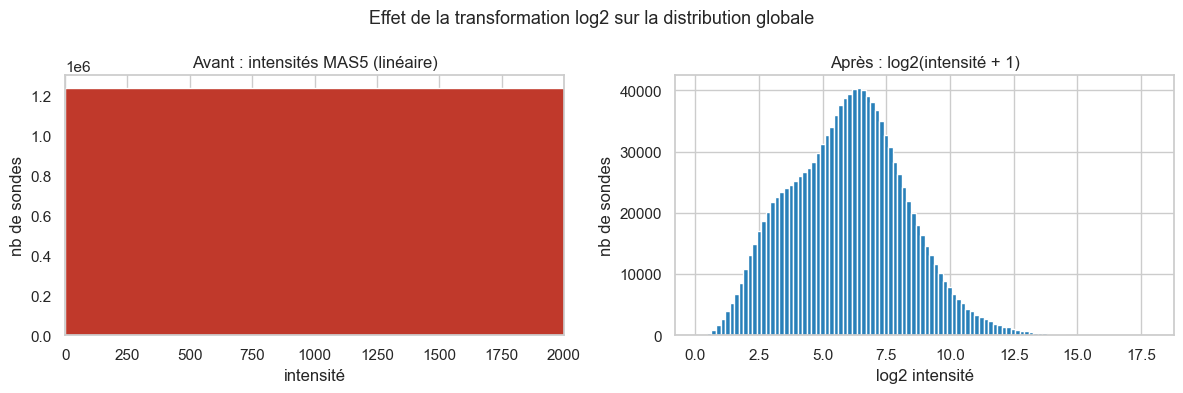

In [5]:
expr_log = prep.log2_transform(expr)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(expr.to_numpy().ravel(), bins=100, color="#c0392b")
axes[0].set(title="Avant : intensités MAS5 (linéaire)", xlabel="intensité", ylabel="nb de sondes")
axes[0].set_xlim(0, 2000)  # zoom : la longue queue va jusqu'à ~245 000

axes[1].hist(expr_log.to_numpy().ravel(), bins=100, color="#2980b9")
axes[1].set(title="Après : log2(intensité + 1)", xlabel="log2 intensité", ylabel="nb de sondes")
fig.suptitle("Effet de la transformation log2 sur la distribution globale", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Normalisation inter-échantillons (quantile)

Avant de comparer AD et contrôles, il faut que les puces soient **comparables entre elles** : une différence de médiane globale entre deux échantillons doit refléter de la biologie, pas un artefact technique (quantité d'ARN, efficacité d'hybridation…).

Le diagnostic de l'étape initiale montrait des médianes par échantillon allant de ~35 à ~117 (rapport ~3,3) : un décalage technique réel. On applique une **quantile normalization**, qui force tous les échantillons à partager la même distribution. C'est la méthode de référence pour les microarrays Affymetrix.

> *Pourquoi quantile plutôt que simple centrage sur la médiane ?* Le centrage n'aligne que la position centrale ; la quantile normalization aligne **toute la forme** de la distribution, ce qui corrige aussi les différences d'étalement entre puces. C'est plus robuste pour une analyse différentielle sonde par sonde.

On visualise les distributions par échantillon (boxplots) avant / après.

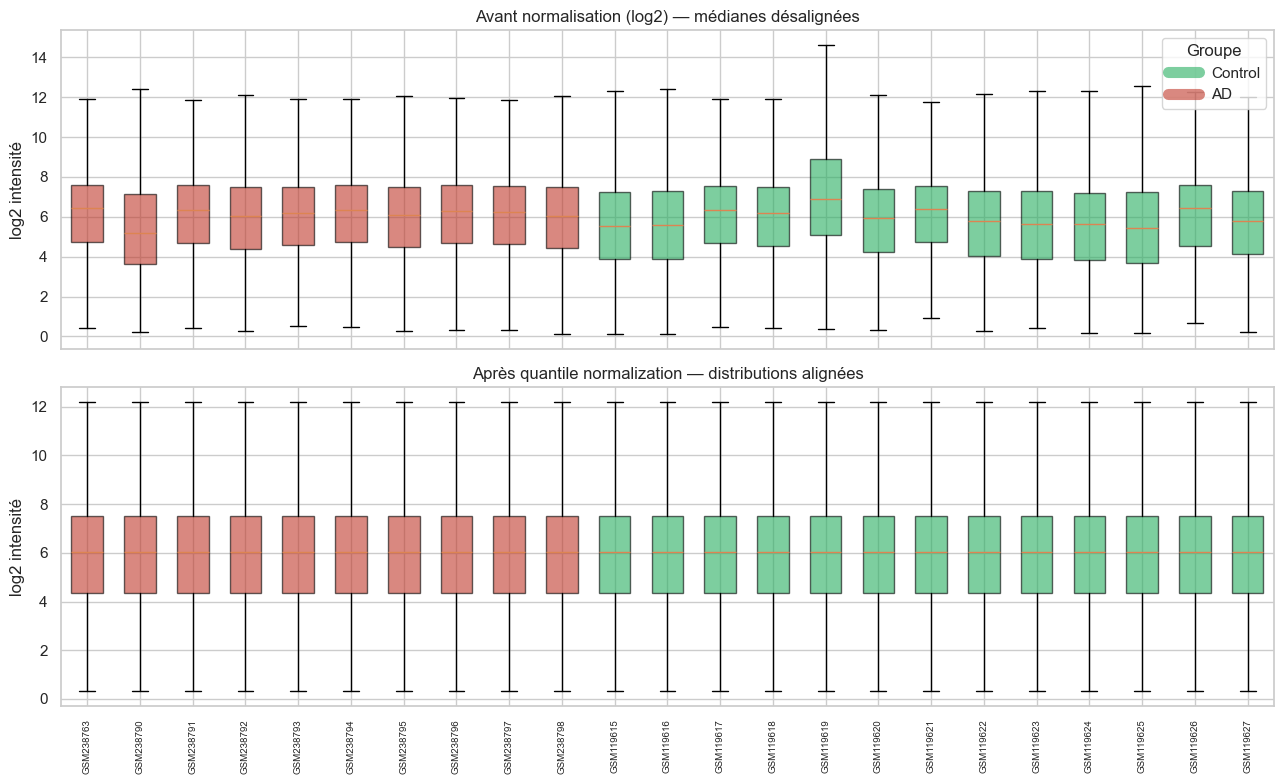

In [6]:
expr_norm = prep.quantile_normalize(expr_log)

# Couleur par groupe pour situer les échantillons
group_color = {"Control": "#27ae60", "AD": "#c0392b"}
colors = [group_color[meta_ec.loc[s, "group"]] for s in expr_log.columns]

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
for ax, data, title in [
    (axes[0], expr_log, "Avant normalisation (log2) — médianes désalignées"),
    (axes[1], expr_norm, "Après quantile normalization — distributions alignées"),
]:
    bp = ax.boxplot(data.to_numpy(), positions=range(data.shape[1]),
                    showfliers=False, patch_artist=True, widths=0.6)
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c); patch.set_alpha(0.6)
    ax.set_ylabel("log2 intensité")
    ax.set_title(title)
axes[1].set_xticks(range(expr_norm.shape[1]))
axes[1].set_xticklabels(expr_norm.columns, rotation=90, fontsize=7)

handles = [plt.Line2D([0], [0], color=c, lw=8, alpha=0.6) for c in group_color.values()]
axes[0].legend(handles, group_color.keys(), title="Groupe", loc="upper right")
plt.tight_layout()
plt.show()

## 6. Diagnostic ABS_CALL — préparer la décision de filtrage

Affymetrix associe à chaque sonde et chaque échantillon un **detection call** (`ABS_CALL`) :
- **P** (*Present*) — transcrit détecté de façon fiable ;
- **M** (*Marginal*) — détection ambiguë ;
- **A** (*Absent*) — signal indistinguable du bruit de fond.

Beaucoup de sondes du U133 Plus 2.0 ciblent des transcrits non exprimés dans le cerveau : elles sont « Absent » dans la quasi-totalité des échantillons et n'apportent que du bruit. Filtrer ces sondes **avant** l'analyse différentielle réduit le nombre de tests (donc allège la pénalité de correction multiple) et améliore la puissance statistique.

Le graphe ci-dessous montre, pour chaque sonde, dans **combien d'échantillons** elle est « Present ». Il sert de base à la décision de seuil (à valider).

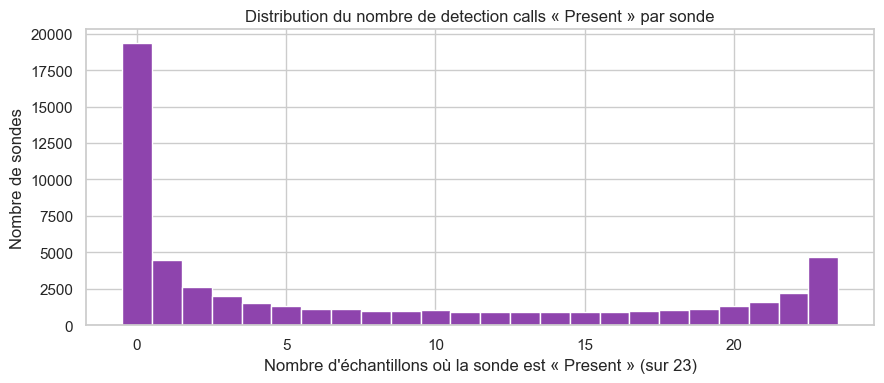

Sondes retenues selon le seuil « Present dans ≥ k échantillons » :
  k ≥  1 :  35351 sondes  (64.7 %)
  k ≥  5 :  24765 sondes  (45.3 %)
  k ≥ 11 :  18190 sondes  (33.3 %)
  k ≥ 23 :   4651 sondes  (8.5 %)

Sondes jamais « Present » (0 échantillon) : 19324


In [7]:
# Matrice des detection calls pour les mêmes échantillons
abscall = gse.pivot_samples("ABS_CALL")[sample_order]
n_samples = abscall.shape[1]

# Nombre d'échantillons où chaque sonde est "Present"
present_per_probe = (abscall == "P").sum(axis=1)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(present_per_probe, bins=range(0, n_samples + 2), color="#8e44ad", align="left")
ax.set(xlabel="Nombre d'échantillons où la sonde est « Present » (sur 23)",
       ylabel="Nombre de sondes",
       title="Distribution du nombre de detection calls « Present » par sonde")
plt.tight_layout()
plt.show()

# Combien de sondes survivraient à différents seuils ?
print("Sondes retenues selon le seuil « Present dans ≥ k échantillons » :")
for k in [1, 5, n_samples // 2, n_samples]:
    n_kept = int((present_per_probe >= k).sum())
    print(f"  k ≥ {k:2d} : {n_kept:6d} sondes  ({100*n_kept/len(present_per_probe):.1f} %)")
print(f"\nSondes jamais « Present » (0 échantillon) : "
      f"{int((present_per_probe == 0).sum())}")

## 7. Sauvegarde des artefacts intermédiaires

On enregistre dans `data/processed/` (non versionné) ce qui sert de point de départ au notebook 03 :
- la matrice d'expression **log2 + quantile-normalisée** (niveau sonde) ;
- la table des **detection calls** (pour le filtrage ABS_CALL à venir) ;
- les **métadonnées** des échantillons EC (groupes AD/contrôle).

Ces artefacts ne dépendent **pas** des deux décisions encore en suspens (filtrage ABS_CALL, collapse sonde → gène), qui seront appliquées au notebook 03.

In [8]:
expr_norm.to_parquet(PROCESSED_DIR / "ec_expr_norm_probe.parquet")
abscall.to_parquet(PROCESSED_DIR / "ec_abscall_probe.parquet")
meta_ec.to_csv(PROCESSED_DIR / "ec_metadata.csv")

print("Artefacts enregistrés dans data/processed/ :")
for f in sorted(PROCESSED_DIR.glob("ec_*")):
    print(f"  {f.name:30s} {f.stat().st_size/1e6:6.2f} Mo")

Artefacts enregistrés dans data/processed/ :
  ec_abscall_probe.parquet         0.68 Mo
  ec_expr_norm_probe.parquet      12.81 Mo
  ec_metadata.csv                  0.00 Mo


## Bilan & décisions en attente

**QC validé :** 23 échantillons de cortex entorhinal (AD vs contrôles), aucune valeur manquante, log2 appliqué, distributions alignées par quantile normalization.

**Deux décisions méthodologiques sont requises avant le notebook 03** (analyse différentielle) :

1. **Filtrage ABS_CALL** — quel seuil de detection call « Present » pour retenir une sonde (voir §6) ?
2. **Collapse sonde → gène** — comment résumer les sondes multiples pointant le même gène (sonde la plus exprimée / moyenne / variance maximale) ?

Ces deux choix sont exposés en détail dans la discussion d'accompagnement ; ils seront implémentés en tête du notebook 03 une fois tranchés.